# Notebook 3: NER Pilot Sample. Entity Distribution and Corpus Categorization
**Luis Mitrovic Balbontín Archive**

Generates FIG. 4 and FIG. 5 of the thesis. FIG. 4 documents the quantitative analysis
of the NER pilot cycle applied to 19 documents from the Mitrovic epistolary archive,
using the LOC/(PER+1) ratio and absolute entity counts to identify non-epistolary
documents. FIG. 5 shows the categorical distribution of the full corpus (n=141).

**Inputs:**
- `data/raw/ner_entities_Luis_Mitrovic_2026-04-20.CSV` — NER output from pilot cycle (19 docs)
- `data/raw/LuisMitrovic_CartasV1.csv` — full corpus metadata (141 docs)

**Outputs:** `figures/fig4_combined.png` · `figures/fig5_category_distribution.png` 

**Key findings:** Documents S3–S7 identified as non-epistolary through LOC/PER anomaly
detection and confirmed by close reading. S10 ratio corrected after NER underdetection
(missed: Luis, Behrens, Bremen). Classification is manual and interpretive, not algorithmic.

In [1]:
from pathlib import Path

BASE     = Path.cwd().parent
DATA_RAW = BASE / "data" / "raw"
FIGURES  = BASE / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print(f"BASE:     {BASE}")
print(f"DATA_RAW: {DATA_RAW}")
print(f"FIGURES:  {FIGURES}")

BASE:     C:\Users\felip\mitrovic-archive
DATA_RAW: C:\Users\felip\mitrovic-archive\data\raw
FIGURES:  C:\Users\felip\mitrovic-archive\figures


In [2]:
# Import libraries 
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import sys
from pathlib import Path

# Path Config 
DATA_FILE = DATA_RAW / "ner_entities_Luis_Mitrovic_2026-04-20.CSV"

# Global configuration of matplotlib
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

print(f"Work Directory : {Path('.').resolve()}")
print(f"Data File      : {DATA_FILE}")
print(f"Found file  : {DATA_FILE.exists()}")

Work Directory : C:\Users\felip\mitrovic-archive\notebooks
Data File      : C:\Users\felip\mitrovic-archive\data\raw\ner_entities_Luis_Mitrovic_2026-04-20.CSV
Found file  : True


In [3]:
# Reproducibility: package versions
print(f"Python     : {sys.version}")
print(f"pandas     : {pd.__version__}")
print(f"matplotlib : {matplotlib.__version__}")
print(f"numpy      : {np.__version__}")

Python     : 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
pandas     : 3.0.0
matplotlib : 3.10.8
numpy      : 2.4.2


In [4]:
# Load NER pilot CSV
df = pd.read_csv(DATA_FILE, encoding="utf-8")

# Initial inspection
print(f"Shape: {df.shape[0]} documents × {df.shape[1]} columns")
print(f"\nColumns:\n{df.dtypes.to_string()}")
print(f"\nFirst rows:")
df.head(19)

Shape: 19 documents × 12 columns

Columns:
letter_id           str
title               str
year              int64
from_person         str
to_person           str
PER_count         int64
PER_list            str
LOC_count         int64
LOC_list            str
ORG_count         int64
ORG_list            str
total_entities    int64

First rows:


,letter_id,title,year,from_person,to_person,PER_count,PER_list,LOC_count,LOC_list,ORG_count,ORG_list,total_entities
0,letter-S10,Carta S10,1937,O. B. Y.,Luis Mitrovic Puljizević,0,NaN,3,Viena;Europa;Chile,1,Academia de Bellas Artes,4
1,letter-S11,Carta S11,1937,Luis Arteaga,Luis Mitrovic Balbontín,2,Luis Arteaga;Arturo Donoso,1,Viena,0,NaN,3
2,letter-S125,Carta S125,1936,Winold Tjark Reiss,Luis Mitrovic Balbontín,3,Winold;Franz;Erick,5,Italy;England;Spain;France;Vienna,0,NaN,8
3,letter-S128,Carta S128,1938,Winold Tjark Reiss,Luis Mitrovic Balbontín,2,Nora;Franz,6,USA;Santiago;Paris;New York;Chile;Vienna,0,NaN,8
4,letter-S129,Carta S129,1939,Winold Tjark Reiss,Luis Mitrovic Balbontín,2,Tjark;Bruce Gimbel,4,Germany;Italy;New York;Chile,1,National Geographic,7
5,letter-S3,Carta S3,1900,Desconocido,Desconocido,6,José Moreno;Alejandro Magno;Darius;Marco Polo;...,15,Rusia;India;Hindu Kush;Afganistán;Andes;Roma;I...,2,Asociación de Fotógrafos;Banco Mundial,23
6,letter-S34,Carta S34,1941,Geo. H. Watson,Luis Mitrovic Balbontín,0,NaN,2,Roma;Chile,1,Chilean Ski Team,3
7,letter-S35,Carta S35,1941,John Jay\r\nc/o Francis Boardman,Luis Mitrovic Balbontín,5,Deborah Bankart;Patty;Julio;Jaime;Frankie,3,Santiago;New York;Chile,0,NaN,8
8,letter-S37,Carta S37,1943,Nora,Luis Mitrovic Balbontín,3,Cucho;Nora;Mary,0,NaN,0,NaN,3
9,letter-S38,Carta S38,1943,Luis Mitrovic Balbontín,Nora,5,Tjark;Sergio Larraín;Mary;Nora;Angela,2,Santiago;England,0,NaN,7


In [5]:
# Extract short ID (S3, S4, ...) for plot labels
df["doc_id"] = df["letter_id"].str.extract(r"letter-(S\d+)")

# Manual classification
NON_EPISTOLAR = {"S3", "S4", "S5", "S6", "S7"}
df["doc_type"] = df["doc_id"].apply(
    lambda x: "Non-epistolary document" if x in NON_EPISTOLAR else "Personal correspondence"
)

# Post-close reading corrections
# Corrections applied after manual validation of NER output.
corrections = {
    "S10": {
        "PER_count": {"original": 0, "corrected": 2,
                      "note": "NER missed: 'Luis', 'Behrens'"},
        "LOC_count": {"original": 3, "corrected": 4,
                      "note": "NER missed: 'Bremen'"},
    }
}

for doc_id, fields in corrections.items():
    for col, vals in fields.items():
        df.loc[df["doc_id"] == doc_id, col] = vals["corrected"]
        print(f"  [{doc_id}] {col}: {vals['original']} → {vals['corrected']} ({vals['note']})")

# Recalculate totals and ratio
df["total_entities"] = df["PER_count"] + df["LOC_count"] + df["ORG_count"]
df["loc_per_ratio"]  = df["LOC_count"] / (df["PER_count"] + 1)

# Sort by ratio descending
df_sorted = df.sort_values("loc_per_ratio", ascending=False).reset_index(drop=True)

# Verification 
print(f"\n── LOC/(PER+1) ratio per document (descending) ─────")
print(df_sorted[["doc_id", "PER_count", "LOC_count", "loc_per_ratio", "doc_type"]]
      .to_string(index=False))

  [S10] PER_count: 0 → 2 (NER missed: 'Luis', 'Behrens')
  [S10] LOC_count: 3 → 4 (NER missed: 'Bremen')

── LOC/(PER+1) ratio per document (descending) ─────
doc_id  PER_count  LOC_count  loc_per_ratio                doc_type
    S6          0          4       4.000000 Non-epistolary document
    S4          3         15       3.750000 Non-epistolary document
    S3          6         15       2.142857 Non-epistolary document
   S34          0          2       2.000000 Personal correspondence
  S128          2          6       2.000000 Personal correspondence
   S10          2          4       1.333333 Personal correspondence
  S129          2          4       1.333333 Personal correspondence
  S125          3          5       1.250000 Personal correspondence
    S8          0          1       1.000000 Personal correspondence
    S7          0          1       1.000000 Non-epistolary document
    S5          2          2       0.666667 Non-epistolary document
   S35          5        

In [6]:
#  Post-close reading corrections
# Corrections applied after manual validation of NER output.
# Each entry documents the document ID, the entity type, the original
# (model) count, the corrected count, and the justification.

# Color definitions
COLOR_NON_EPISTOLARY = "#1a1a1a"
COLOR_PERSONAL       = "#a0a0a0"
COLOR_THRESHOLD      = "#555555"

C_PER = "#2E8B57"
C_LOC = "#E07B39"
C_ORG = "#4A6FA5"

# Corrections
corrections = {
    "S10": {
        "PER_count": {"original": 0, "corrected": 2,
                      "note": "NER missed: 'Luis', 'Behrens'"},
        "LOC_count": {"original": 3, "corrected": 4,
                      "note": "NER missed: 'Bremen'"},
    }
}

# Apply corrections to df_sorted and df
for doc_id, fields in corrections.items():
    for col, vals in fields.items():
        df.loc[df["doc_id"] == doc_id, col] = vals["corrected"]
        print(f"  [{doc_id}] {col}: {vals['original']} → {vals['corrected']} ({vals['note']})")

# Recalculate total_entities and loc_per_ratio after corrections
df["total_entities"] = df["PER_count"] + df["LOC_count"] + df["ORG_count"]
df["loc_per_ratio"]  = df["LOC_count"] / (df["PER_count"] + 1)

# Re-sort by ratio descending
df_sorted = df.sort_values("loc_per_ratio", ascending=False).reset_index(drop=True)

# Recalculate x axis and bar colors aligned to new order
x          = np.arange(len(df_sorted))
DOC_ORDER  = df_sorted["doc_id"].tolist()
bar_colors = [
    COLOR_NON_EPISTOLARY if t == "Non-epistolary document" else COLOR_PERSONAL
    for t in df_sorted["doc_type"]
]

# Recalculate mean ratio for personal correspondence (used in Panel A threshold)
mean_personal = df_sorted[
    df_sorted["doc_type"] == "Personal correspondence"
]["loc_per_ratio"].mean()

print(f"\nCorrected LOC/(PER+1) for S10: {df_sorted.loc[df_sorted['doc_id']=='S10', 'loc_per_ratio'].values[0]:.4f}")
print(f"Updated mean ratio – personal correspondence: {mean_personal:.4f}")
print(f"\nNew document order: {DOC_ORDER}")

  [S10] PER_count: 0 → 2 (NER missed: 'Luis', 'Behrens')
  [S10] LOC_count: 3 → 4 (NER missed: 'Bremen')

Corrected LOC/(PER+1) for S10: 1.3333
Updated mean ratio – personal correspondence: 0.7488

New document order: ['S6', 'S4', 'S3', 'S34', 'S128', 'S10', 'S129', 'S125', 'S8', 'S7', 'S5', 'S35', 'S39', 'S11', 'S38', 'S37', 'S42', 'S48', 'S52']


In [7]:
# Shared visual variables for FIG. 5 (Panel A and B) 

# Document order: sorted by LOC/PER ratio descending (established in Cell 4)
DOC_ORDER = df_sorted["doc_id"].tolist()
x = np.arange(len(DOC_ORDER))

# Color vector aligned to DOC_ORDER
bar_colors = [
    COLOR_NON_EPISTOLARY if t == "Non-epistolary document" else COLOR_PERSONAL
    for t in df_sorted["doc_type"]
]

# Legend patches (reused in both panels and combined figure)
patch_non_ep = mpatches.Patch(color=COLOR_NON_EPISTOLARY, label="Non-epistolary document")
patch_personal = mpatches.Patch(color=COLOR_PERSONAL, label="Personal correspondence")

print("Shared variables defined.")
print(f"Document order ({len(DOC_ORDER)}): {DOC_ORDER}")

Shared variables defined.
Document order (19): ['S6', 'S4', 'S3', 'S34', 'S128', 'S10', 'S129', 'S125', 'S8', 'S7', 'S5', 'S35', 'S39', 'S11', 'S38', 'S37', 'S42', 'S48', 'S52']


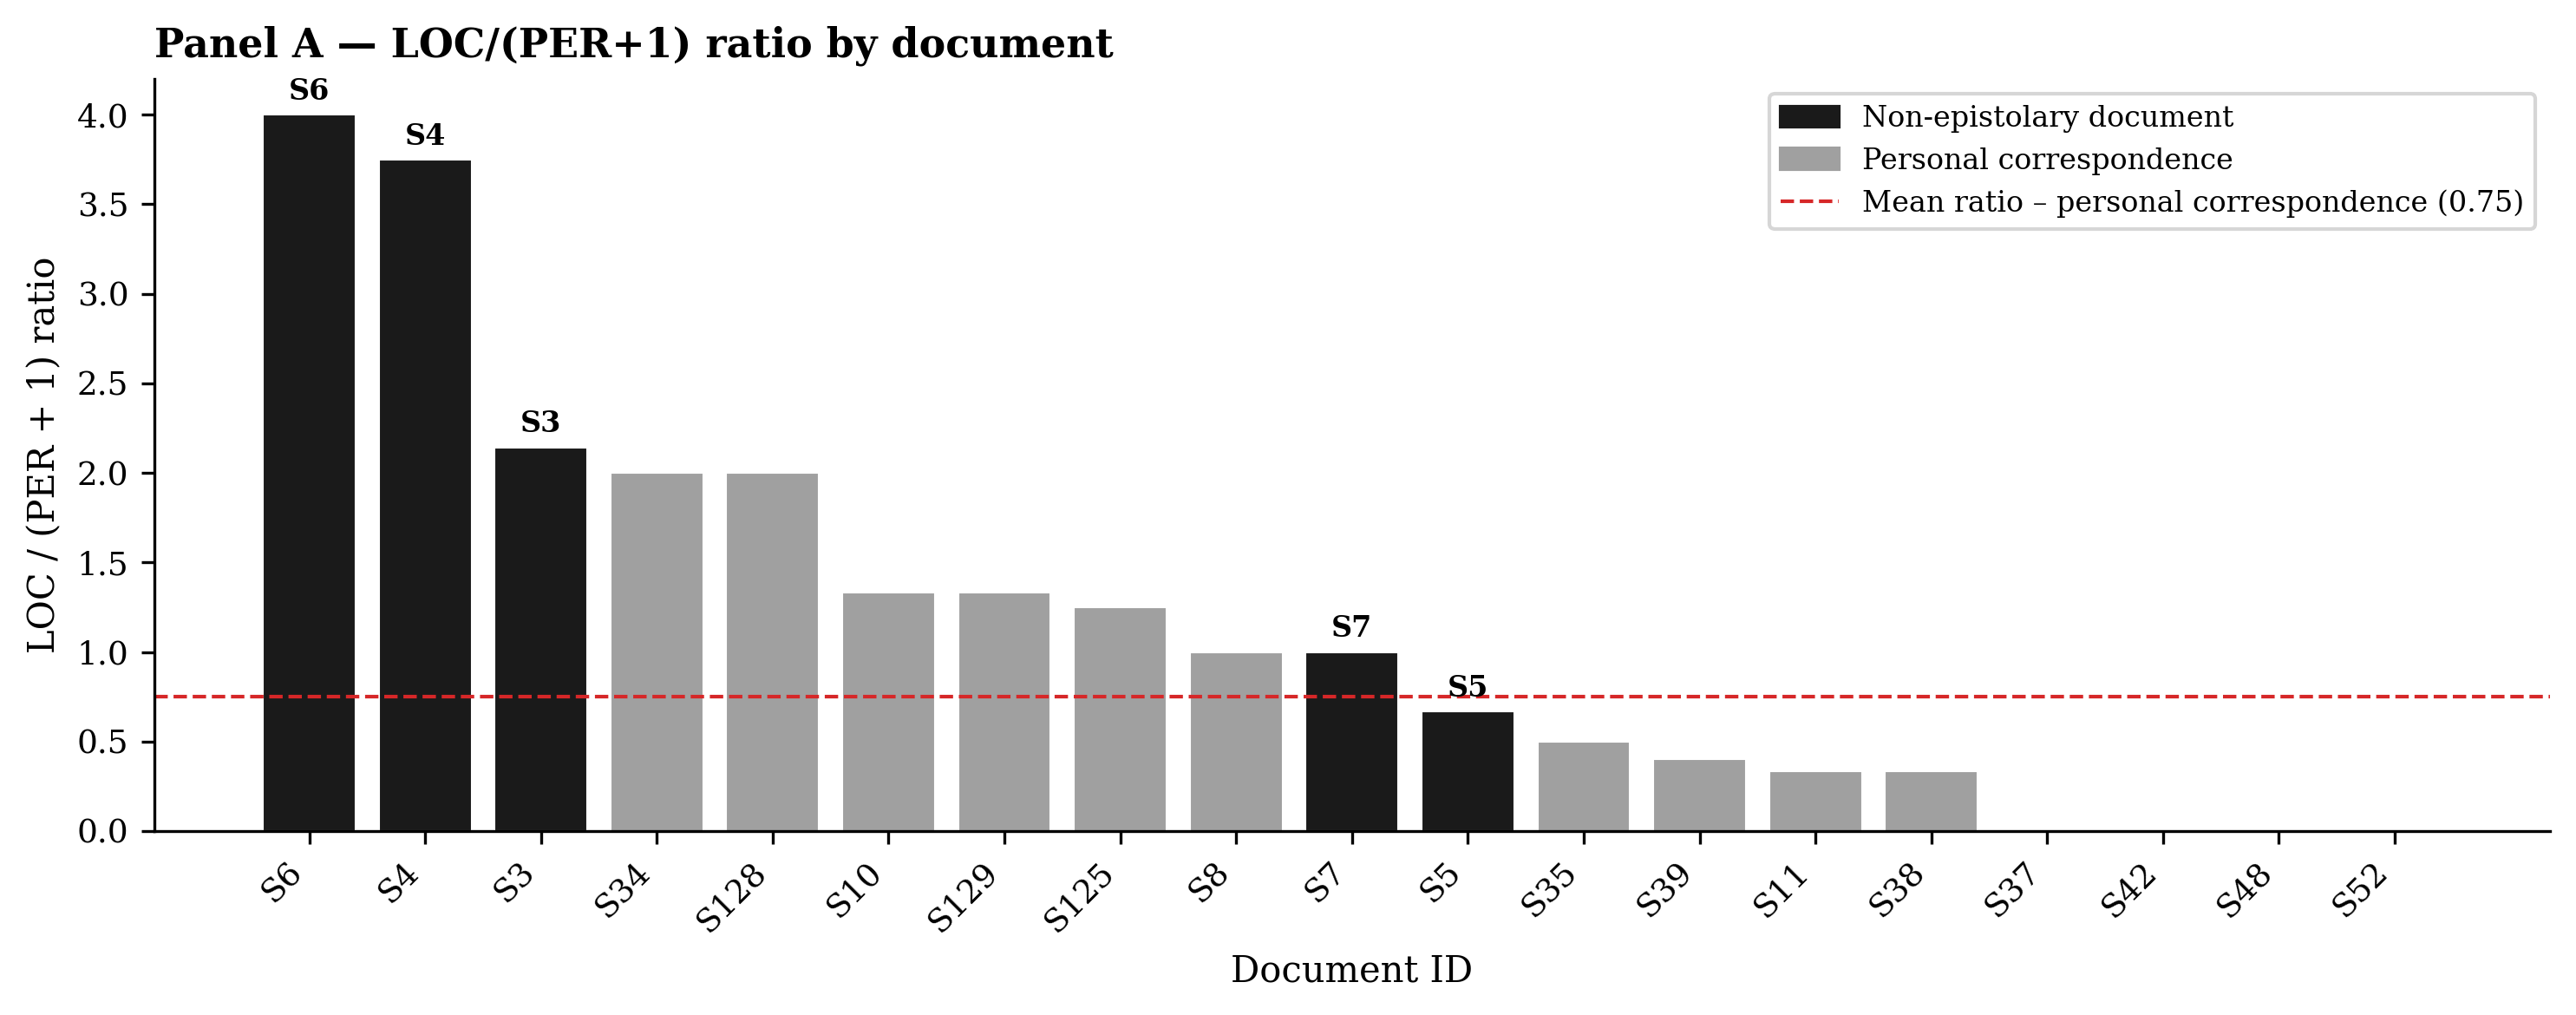

Mean ratio personal correspondence: 0.7488


In [8]:
# Panel A: LOC/(PER+1) ratio per document 
import matplotlib.lines as mlines

fig_a, ax_a = plt.subplots(figsize=(10, 4))

# Bars
ax_a.bar(x, df_sorted["loc_per_ratio"], color=bar_colors, edgecolor="white", linewidth=0.5)

# Threshold line in red
mean_personal = df_sorted[df_sorted["doc_type"] == "Personal correspondence"]["loc_per_ratio"].mean()
ax_a.axhline(mean_personal, color="#d62728", linestyle="--", linewidth=1.0)

# Annotate non-epistolary bars with their doc_id
for i, row in df_sorted.iterrows():
    if row["doc_type"] == "Non-epistolary document":
        ax_a.text(df_sorted.index.get_loc(i), row["loc_per_ratio"] + 0.05,
                  row["doc_id"], ha="center", va="bottom", fontsize=8,
                  fontweight="bold")

# Axes
ax_a.set_xticks(x)
ax_a.set_xticklabels(DOC_ORDER, rotation=45, ha="right")
ax_a.set_xlabel("Document ID")
ax_a.set_ylabel("LOC / (PER + 1) ratio")
ax_a.set_title("Panel A — LOC/(PER+1) ratio by document", loc="left", fontweight="bold")

# Legend — threshold as Line2D (dashed red)
threshold_line = mlines.Line2D([], [], color="#d62728", linestyle="--",
                                linewidth=1.0,
                                label=f"Mean ratio – personal correspondence ({mean_personal:.2f})")
ax_a.legend(handles=[patch_non_ep, patch_personal, threshold_line], fontsize=8)

ax_a.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES / "fig5_panel_a.png")
plt.show()
print(f"Mean ratio personal correspondence: {mean_personal:.4f}")

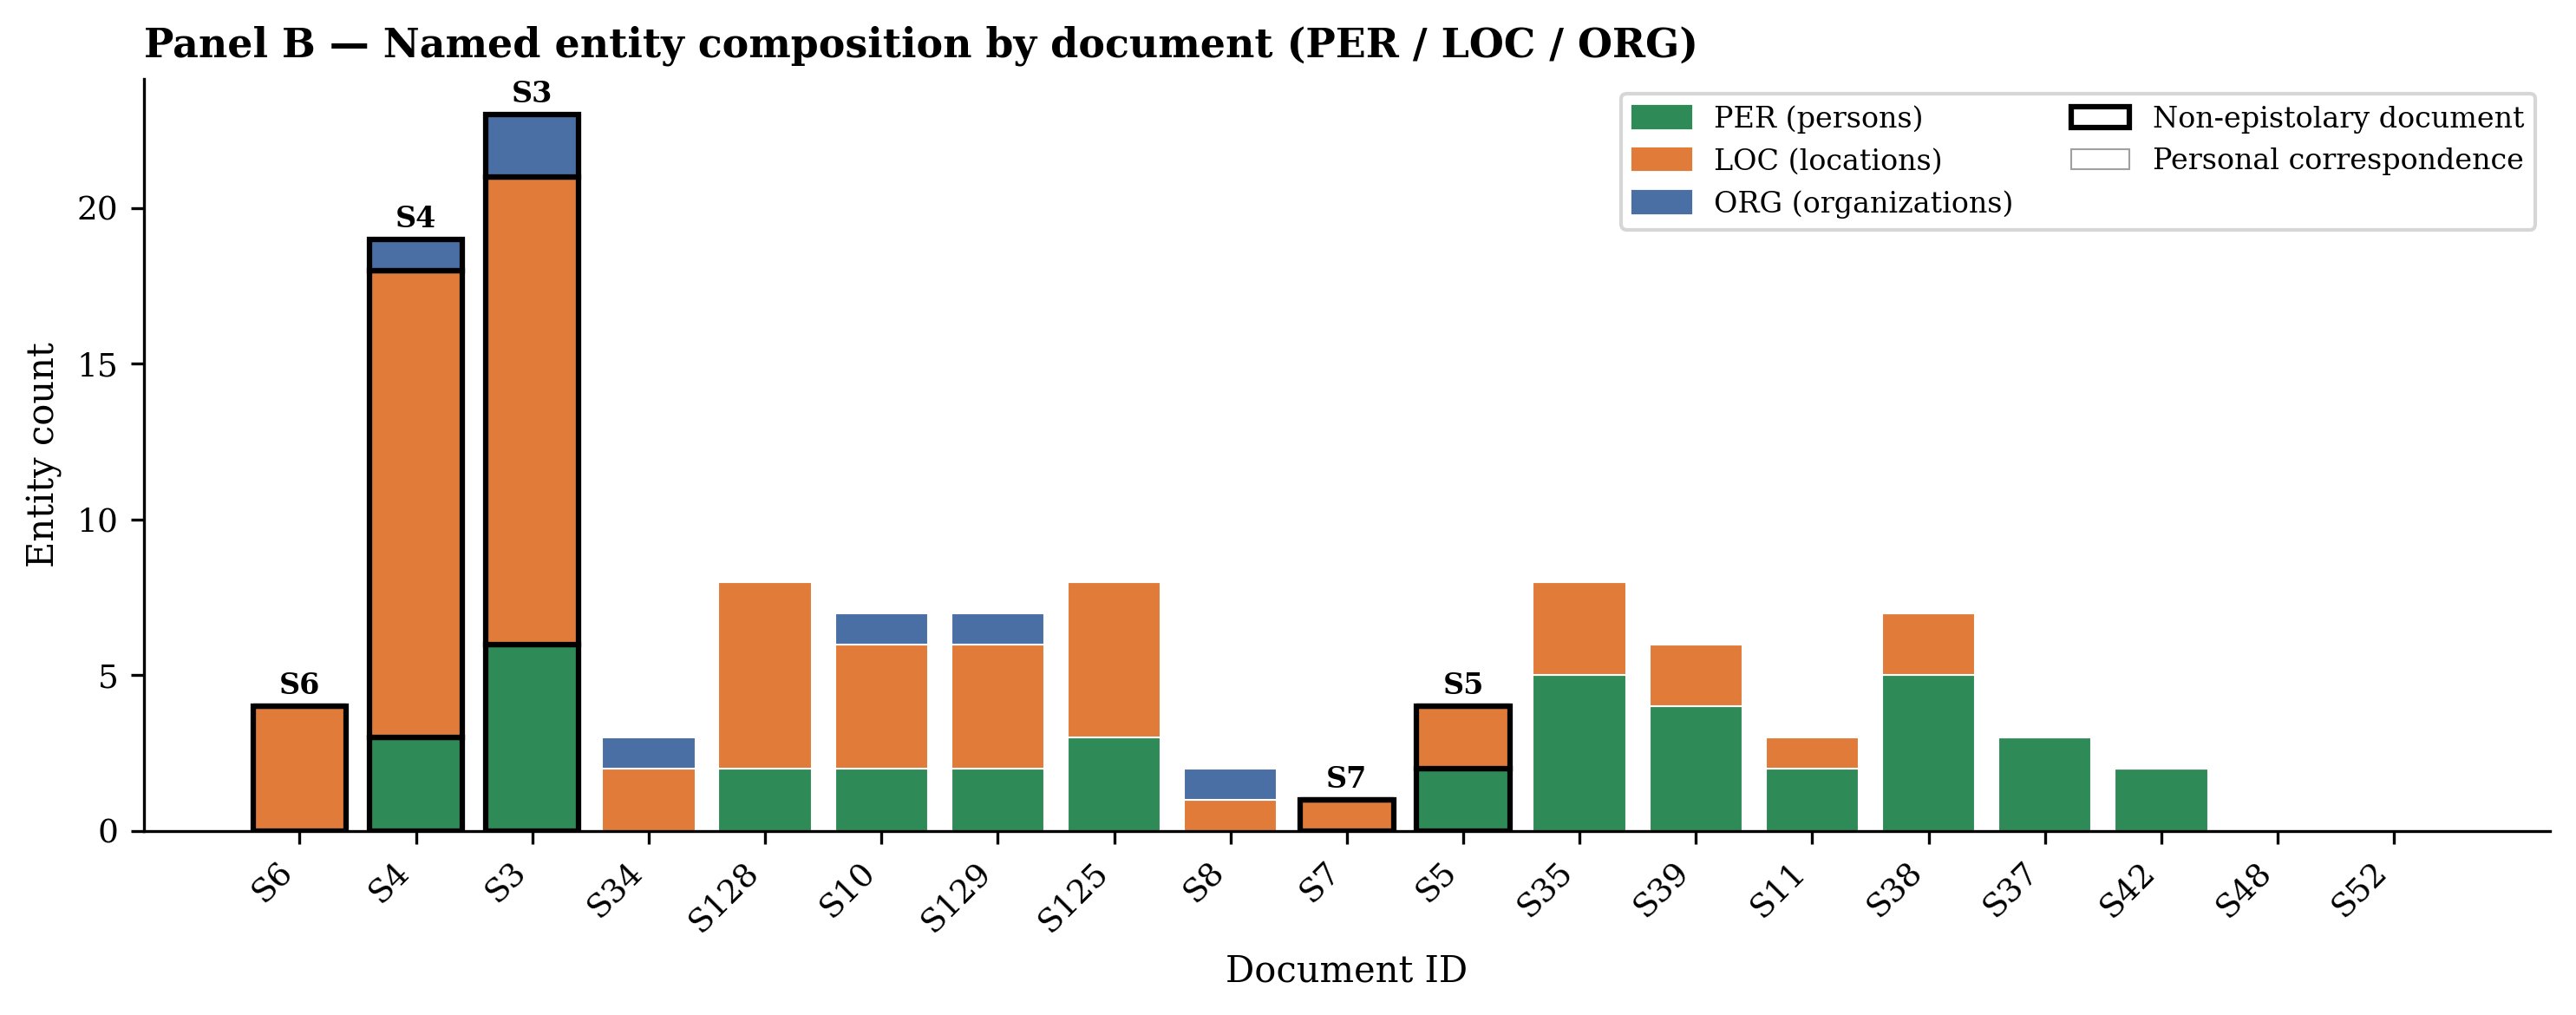

In [9]:
# Panel B: stacked bar chart — PER, LOC, ORG entity counts (Set2 palette)
fig_b, ax_b = plt.subplots(figsize=(10, 4))

# Set2 palette — first 3 colors
C_PER = "#2E8B57"   # Persons — semantic palette
C_LOC = "#E07B39"   # Locations — semantic palette
C_ORG = "#4A6FA5"   # Organizations — semantic palette

# Extract counts in DOC_ORDER
per_vals = df_sorted["PER_count"].values
loc_vals = df_sorted["LOC_count"].values
org_vals = df_sorted["ORG_count"].values

# Edge color: black for non-epistolary, none for personal
edge_colors = [
    "black" if t == "Non-epistolary document" else "white"
    for t in df_sorted["doc_type"]
]
edge_widths = [
    1.5 if t == "Non-epistolary document" else 0.5
    for t in df_sorted["doc_type"]
]

# Stacked bars
for i in range(len(x)):
    ax_b.bar(x[i], per_vals[i], color=C_PER,
             edgecolor=edge_colors[i], linewidth=edge_widths[i])
    ax_b.bar(x[i], loc_vals[i], bottom=per_vals[i], color=C_LOC,
             edgecolor=edge_colors[i], linewidth=edge_widths[i])
    ax_b.bar(x[i], org_vals[i], bottom=per_vals[i] + loc_vals[i], color=C_ORG,
             edgecolor=edge_colors[i], linewidth=edge_widths[i])

# Label non-epistolary documents above bar
for i, row in df_sorted.iterrows():
    if row["doc_type"] == "Non-epistolary document":
        total = row["PER_count"] + row["LOC_count"] + row["ORG_count"]
        ax_b.text(df_sorted.index.get_loc(i), total + 0.2,
                  row["doc_id"], ha="center", va="bottom", fontsize=8,
                  fontweight="bold")

# Axes
ax_b.set_xticks(x)
ax_b.set_xticklabels(DOC_ORDER, rotation=45, ha="right")
ax_b.set_xlabel("Document ID")
ax_b.set_ylabel("Entity count")
ax_b.set_title("Panel B — Named entity composition by document (PER / LOC / ORG)",
               loc="left", fontweight="bold")

# Legend
entity_handles = [
    mpatches.Patch(color=C_PER, label="PER (persons)"),
    mpatches.Patch(color=C_LOC, label="LOC (locations)"),
    mpatches.Patch(color=C_ORG, label="ORG (organizations)"),
]
# Non-epistolary: black border patch
non_ep_patch = mpatches.Patch(facecolor="white", edgecolor="black",
                               linewidth=1.5, label="Non-epistolary document")
personal_patch = mpatches.Patch(facecolor="white", edgecolor="#a0a0a0",
                                 linewidth=0.5, label="Personal correspondence")

ax_b.legend(handles=entity_handles + [non_ep_patch, personal_patch], fontsize=8, ncol=2)

ax_b.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES / "fig5_panel_b.png")
plt.show()

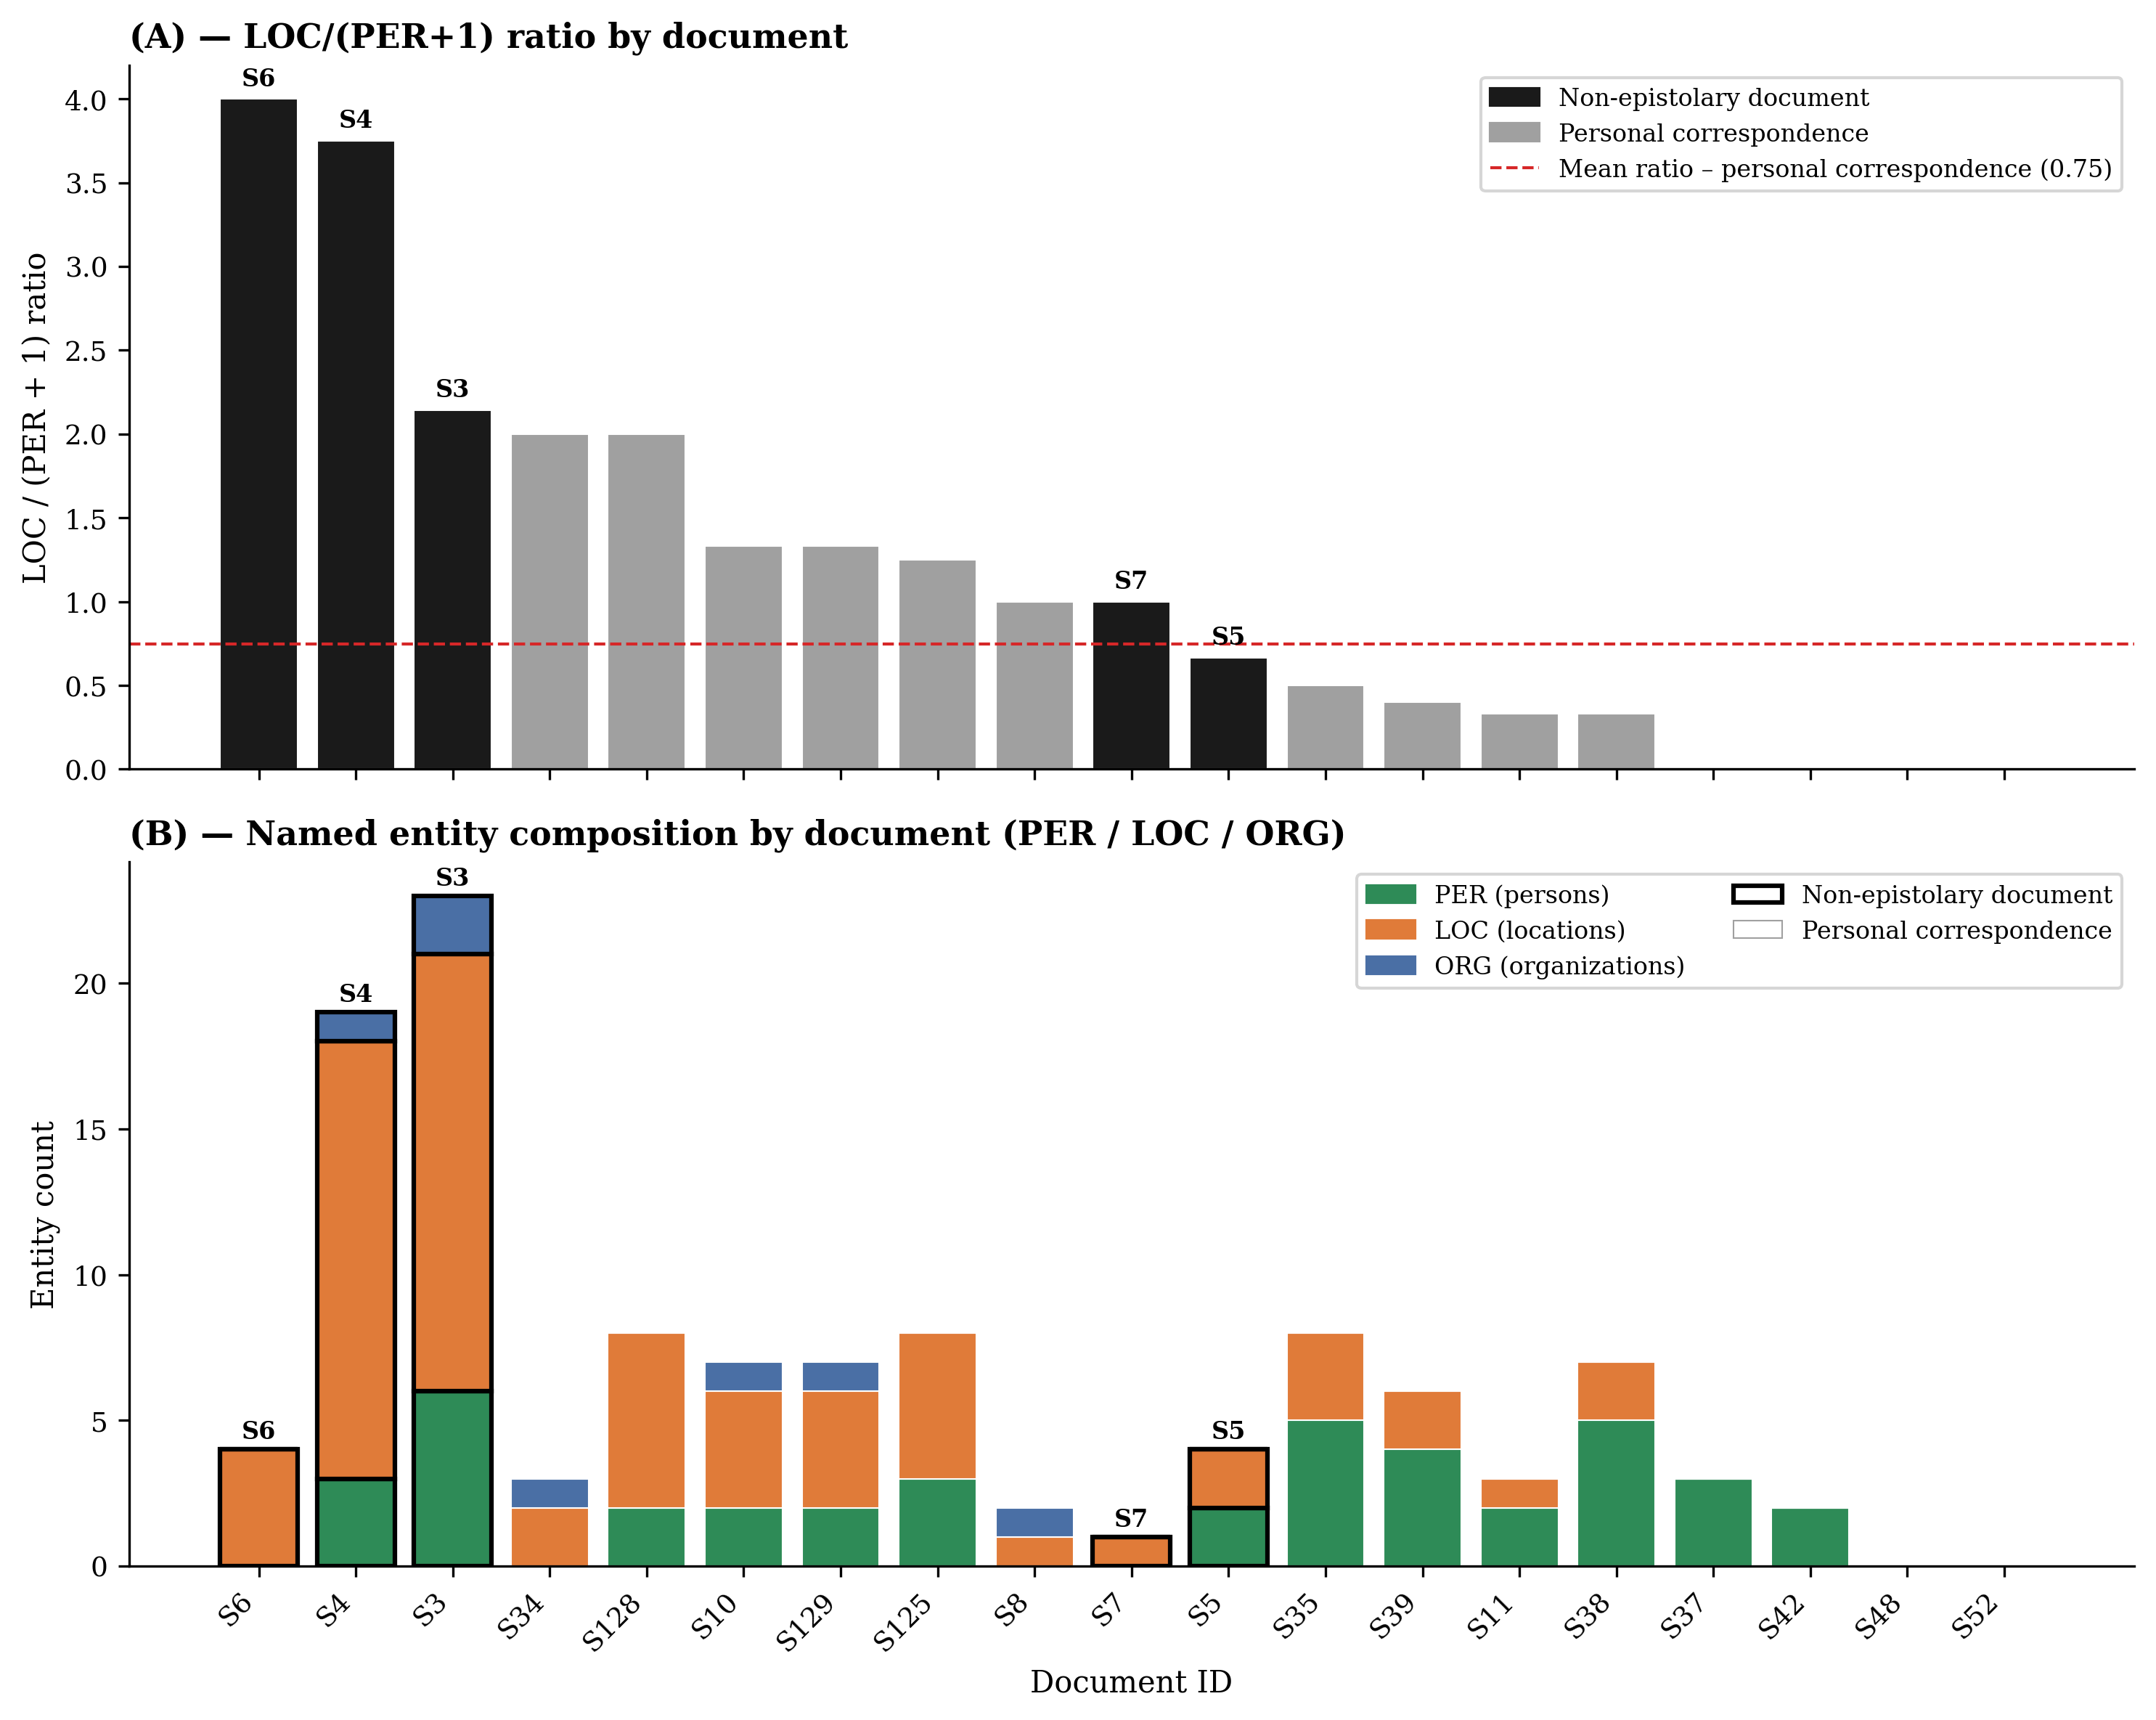

FIG. 4 exported: fig4_combined.png


In [10]:
# FIG. 4. Combined figure: Panel A + Panel B 
fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# PANEL A — LOC/(PER+1) ratio 
ax_a.bar(x, df_sorted["loc_per_ratio"], color=bar_colors, edgecolor="white", linewidth=0.5)

ax_a.axhline(mean_personal, color="#d62728", linestyle="--", linewidth=1.0)

for i, row in df_sorted.iterrows():
    if row["doc_type"] == "Non-epistolary document":
        ax_a.text(df_sorted.index.get_loc(i), row["loc_per_ratio"] + 0.05,
                  row["doc_id"], ha="center", va="bottom", fontsize=8,
                  fontweight="bold")

ax_a.set_ylabel("LOC / (PER + 1) ratio")
ax_a.set_title("(A) — LOC/(PER+1) ratio by document", loc="left", fontweight="bold")
ax_a.spines[["top", "right"]].set_visible(False)

threshold_line = mlines.Line2D([], [], color="#d62728", linestyle="--",
                                linewidth=1.0,
                                label=f"Mean ratio – personal correspondence ({mean_personal:.2f})")
ax_a.legend(handles=[patch_non_ep, patch_personal, threshold_line], fontsize=8)

# PANEL B — Stacked entity counts 
C_PER = "#2E8B57"   # Persons — semantic palette
C_LOC = "#E07B39"   # Locations — semantic palette
C_ORG = "#4A6FA5"   # Organizations — semantic palette

per_vals = df_sorted["PER_count"].values
loc_vals = df_sorted["LOC_count"].values
org_vals = df_sorted["ORG_count"].values

edge_colors = ["black" if t == "Non-epistolary document" else "white"
               for t in df_sorted["doc_type"]]
edge_widths = [1.5 if t == "Non-epistolary document" else 0.5
               for t in df_sorted["doc_type"]]

for i in range(len(x)):
    ax_b.bar(x[i], per_vals[i], color=C_PER,
             edgecolor=edge_colors[i], linewidth=edge_widths[i])
    ax_b.bar(x[i], loc_vals[i], bottom=per_vals[i], color=C_LOC,
             edgecolor=edge_colors[i], linewidth=edge_widths[i])
    ax_b.bar(x[i], org_vals[i], bottom=per_vals[i] + loc_vals[i], color=C_ORG,
             edgecolor=edge_colors[i], linewidth=edge_widths[i])

for i, row in df_sorted.iterrows():
    if row["doc_type"] == "Non-epistolary document":
        total = row["PER_count"] + row["LOC_count"] + row["ORG_count"]
        ax_b.text(df_sorted.index.get_loc(i), total + 0.2,
                  row["doc_id"], ha="center", va="bottom", fontsize=8,
                  fontweight="bold")

ax_b.set_xticks(x)
ax_b.set_xticklabels(DOC_ORDER, rotation=45, ha="right")
ax_b.set_xlabel("Document ID")
ax_b.set_ylabel("Entity count")
ax_b.set_title("(B) — Named entity composition by document (PER / LOC / ORG)",
               loc="left", fontweight="bold")
ax_b.spines[["top", "right"]].set_visible(False)

entity_handles = [
    mpatches.Patch(color=C_PER, label="PER (persons)"),
    mpatches.Patch(color=C_LOC, label="LOC (locations)"),
    mpatches.Patch(color=C_ORG, label="ORG (organizations)"),
]
non_ep_patch = mpatches.Patch(facecolor="white", edgecolor="black",
                               linewidth=1.5, label="Non-epistolary document")
personal_patch = mpatches.Patch(facecolor="white", edgecolor="#a0a0a0",
                                 linewidth=0.5, label="Personal correspondence")
ax_b.legend(handles=entity_handles + [non_ep_patch, personal_patch], fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(FIGURES / "fig4_combined.png", dpi=300, bbox_inches="tight")
plt.show()

print("FIG. 4 exported: fig4_combined.png")

## Methodological notes

- **NER pilot scope**: 19 documents from the Luis Mitrovic Balbontín archive (Fundación Enterreno).
- **Entity categories**: PER (persons), LOC (locations), ORG (organizations).
- **LOC/(PER+1) ratio**: additive smoothing (+1) applied to PER denominator to avoid
  zero-division.
- **Non-epistolary classification**: documents S3–S7 identified through close reading
  after NER anomaly detection. Classification is manual and interpretive, not algorithmic.
- **S10 note**: elevated LOC/(PER+1) ratio (3.0) attributable to NER underdetection —
  close reading confirmed missing entities: PER (Luis, Behrens) and LOC (Bremen).
  Document remains classified as personal correspondence.
- **Output files**: `fig5_combined.png` (300 dpi).

In [11]:
df_sorted[df_sorted["doc_id"] == "S10"][["doc_id", "PER_count", "LOC_count", "ORG_count", "loc_per_ratio"]]

,doc_id,PER_count,LOC_count,ORG_count,loc_per_ratio
5,S10,2,4,1,1.333333


# FIG. 5: Document type distribution across the full corpus

**Corpus:** Luis Mitrovic Balbontín archivE. Full catalogue (n=141)  
**Source file:** `LuisMitrovic_Cartas.csv`

This section generates Figure 5 of the thesis, corresponding to the categorical
distribution of the full digitised corpus. Unlike the NER pilot (FIG. 4), which
operated on a 19-document sample, this figure reflects the complete curation
of 141 documents classified using the following typology:

| Category | Description |
|---|---|
| `personal_letter` | Private correspondence between individuals |
| `professional_letter` | Correspondence related to architectural or professional work |
| `institutional_letter` | Letters involving institutions, organisations, or formal bodies |
| `non_epistolary_authored` | Non-letter documents authored by Mitrovic (reports, memos) |
| `non_epistolary_collected` | Non-letter documents collected by Mitrovic (clippings, pamphlets) |


In [12]:
# Load full corpus CSV
DATA_FILE_CORPUS = DATA_RAW / "LuisMitrovic_CartasV1.csv"

df_corpus = pd.read_csv(
    DATA_FILE_CORPUS,
    encoding="utf-8-sig",
    sep=";",
    quotechar='"',
    quoting=0,          # QUOTE_MINIMAL 
    engine="python"     
)

# Initial inspection
print(f"── Shape ───────")
print(f"  {df_corpus.shape[0]} documents × {df_corpus.shape[1]} columns\n")

print("── Columns ──────")
print(df_corpus.dtypes.to_string())

print("\n── Category distribution ─────")
print(df_corpus["category"].value_counts().to_string())

print(f"\n── Null values in category ─────")
print(f"  {df_corpus['category'].isna().sum()} nulls")

── Shape ───────
  141 documents × 13 columns

── Columns ──────
Unnamed: 0       str
Filename         str
Content          str
placeFrom        str
placeTo          str
Notes            str
To               str
From             str
Date             str
Attached Item    str
Language         str
Type             str
category         str

── Category distribution ─────
category
personal_letter             112
institutional_letter         19
non_epistolary_collected      4
non_epistolary_authored       3
professional_letter           3

── Null values in category ─────
  0 nulls


In [13]:
# Prepare data for FIG. 5

# Category display labels (ordered by count descending)
CATEGORY_LABELS = {
    "personal_letter":          "Personal letter",
    "institutional_letter":     "Institutional letter",
    "non_epistolary_collected": "Non-epistolary (collected)",
    "non_epistolary_authored":  "Non-epistolary (authored)",
    "professional_letter":      "Professional letter",
}

# Count and sort descending
cat_counts = (df_corpus["category"]
              .value_counts()
              .reset_index())
cat_counts.columns = ["category", "count"]
cat_counts["label"] = cat_counts["category"].map(CATEGORY_LABELS)
cat_counts["pct"]   = (cat_counts["count"] / cat_counts["count"].sum() * 100).round(1)

# Grayscale palette. 5 shades from dark to light
GRAY_PALETTE = ["#1a1a1a", "#555555", "#888888", "#b0b0b0", "#d4d4d4"]

print("── Category counts ───")
print(cat_counts[["label", "count", "pct"]].to_string(index=False))

── Category counts ───
                     label  count  pct
           Personal letter    112 79.4
      Institutional letter     19 13.5
Non-epistolary (collected)      4  2.8
 Non-epistolary (authored)      3  2.1
       Professional letter      3  2.1


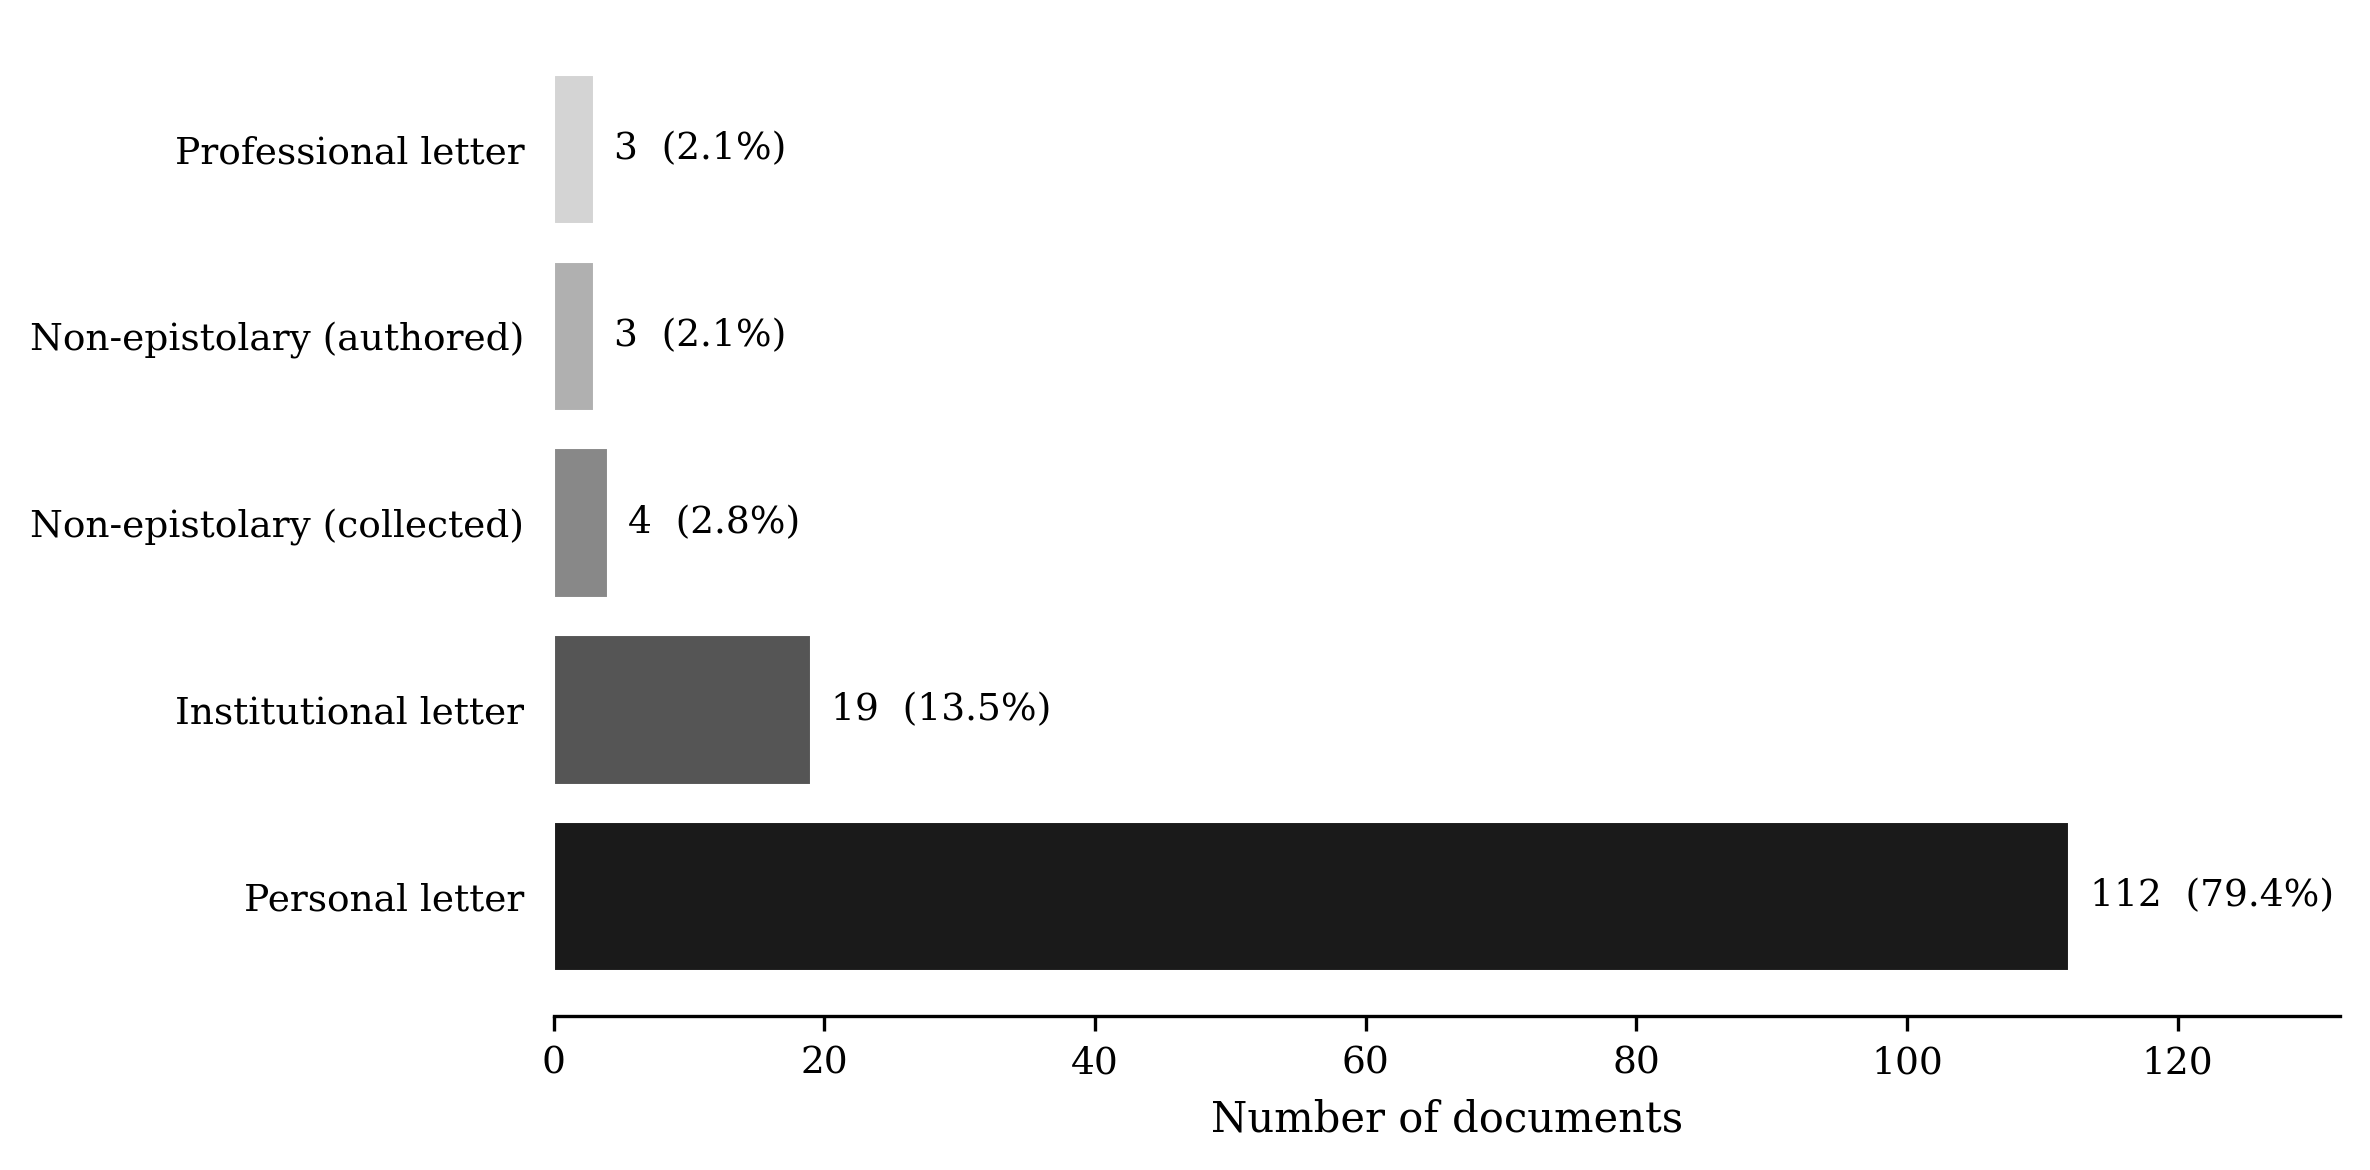

FIG. 5 exported: fig5_category_distribution.png


In [14]:
# FIG. 5. Category distribution across the full corpus
fig6, ax6 = plt.subplots(figsize=(8, 4))

bars = ax6.barh(
    cat_counts["label"],
    cat_counts["count"],
    color=GRAY_PALETTE,
    edgecolor="white",
    linewidth=0.5
)

# Annotate bars with count and percentage
for bar, (_, row) in zip(bars, cat_counts.iterrows()):
    ax6.text(
        bar.get_width() + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"{row['count']}  ({row['pct']}%)",
        va="center", ha="left", fontsize=9
    )

# Axes
ax6.set_xlabel("Number of documents")
ax6.set_xlim(0, cat_counts["count"].max() + 20)
ax6.spines[["top", "right", "left"]].set_visible(False)
ax6.tick_params(left=False)

plt.tight_layout()
plt.savefig(FIGURES / "fig5_category_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("FIG. 5 exported: fig5_category_distribution.png")